In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd

# Plot-Formatierung
plt.rcParams['font.size'] = 24.0
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['lines.linewidth'] = 2.0

In [21]:
# tab = Table.read("C:/Users/Ruben/Desktop/All_candidates_white_dwarfs.vot") #hier keine gefunden wegen T_eff

tab40 = pd.read_csv("./full sample 40pc.csv")
id3_str = ','.join(map(str, np.array(tab40["DR3_source_id"])))
with open("./40pc_DR3_source_id.txt", 'w') as f:
    f.write(id3_str)

column_names = ["ID", "Gaia", "RAdeg", "DEdeg", "plx", "e_plx", "pmRA", "e_pmRA", "pmDE", "e_pmDE", "Gmag", "GBP", "GRP"]
column_widths = [(0, 10), (11, 30), (31, 40), (41, 50), (51, 57), (58, 62), (63, 70), (71, 74), (75, 82), (83, 86), (87, 92), (93, 98), (99, 104)]
colspecs = [(start, end+1) for start, end in column_widths]

tab100 = pd.read_fwf("./almost full sample 100pc.txt", colspecs=colspecs, names=column_names, skiprows=23)
id2_str = ','.join(map(str, np.array(tab100["Gaia"])))
with open("./100pc_DR2_source_id.txt", 'w') as f:
    f.write(id2_str)

trans = Table.read("./100pc_source_id_trans.vot")
# print('Wo unterscheiden sich DR2 und DR3 source ids?? ', np.where(np.array(trans["dr2_source_id"]) != np.array(trans["dr3_source_id"])))
id3_str = ','.join(map(str, np.array(trans["dr3_source_id"])))
with open("./100pc_DR3_source_id.txt", 'w') as f:
    f.write(id3_str)


tab40_gaia = Table.read("./40pc_white_dwarfs.vot", format="votable")
# print(np.array(tab40_gaia['teff_gspphot'])[~np.isnan(np.array(tab40_gaia['teff_gspphot']))])
print(np.array(tab40_gaia['radial_velocity'])[~np.isnan(np.array(tab40_gaia['radial_velocity']))])

tab100_gaia = Table.read("./100pc_white_dwarfs.vot", format="votable")
# print(np.array(tab100_gaia['teff_gspphot'])[~np.isnan(np.array(tab100_gaia['teff_gspphot']))])
print(np.array(tab40_gaia['radial_velocity'])[~np.isnan(np.array(tab40_gaia['radial_velocity']))])

[-414.01544 -373.73666]
[-414.01544 -373.73666]


In [27]:
deg2rad = np.pi/180.

def r_from_plx(plx):
    '''From parallax in mas to distance in pc'''
    return np.abs(1./np.tan(1e-3*plx))

def M_d_to_m(M, d):
    '''Absolute magnitude M in mag, distance in pc, to apparent magnitude m in mag'''
    m = M + 5.*np.log10(d) - 5.
    return m

def ra_dec_to_l_b(ra, dec):
    '''From ra and dec in degrees to l and b in degrees'''
    # See http://www.iausofa.org/2023_1011_C/sofa/icrs2g.c
    deg2rad = np.pi/180.
    deltaG = 27.12825 * deg2rad
    alphaG = 192.85948 * deg2rad
    l_ANGE = 32.93192 * deg2rad
    _ra = ra * deg2rad
    _dec = dec * deg2rad
    
    b = np.arcsin(np.cos(_dec)*np.cos(deltaG)*np.cos(_ra-alphaG)+np.sin(_dec)*np.sin(deltaG))
    x = np.sin(_ra-alphaG)*np.cos(_dec)
    y = np.sin(_dec)*np.cos(deltaG)-np.cos(_dec)*np.sin(deltaG)*np.cos(_ra-alphaG)
    
    l = np.arctan2(y, x) + l_ANGE
    l = np.mod(l, 2.*np.pi)
    
    return l/deg2rad, b/deg2rad

dist_pc_40 = r_from_plx(np.array(tab40["parallax"])) # in pc
z_pc_40 = dist_pc_40 * np.sin(ra_dec_to_l_b(tab40["ra"], tab40["dec"])[1]*deg2rad) +14.5
absolute_magnitude_40 = np.array(tab40["absG"])
teff_40 = np.array(tab40["gaia_teff"]) # in K

dist_pc_40g = r_from_plx(np.array(tab40_gaia["parallax"])) # in pc
z_pc_40g = dist_pc_40g * np.sin(np.array(tab40_gaia["b"])*deg2rad) +14.5
apparent_magnitude_40g = np.array(tab40_gaia["phot_g_mean_mag"])
absolute_magnitude_40g = apparent_magnitude_40g - 5.*np.log10(dist_pc_40g) + 5.


dist_pc_100 = r_from_plx(np.array(tab100["plx"])) # in pc
z_pc_100 = dist_pc_100 * np.sin(ra_dec_to_l_b(tab100["RAdeg"], tab100["DEdeg"])[1]*deg2rad) +14.5
apparent_magnitude_100 = np.array(tab100["Gmag"])
absolute_magnitude_100 = apparent_magnitude_100 - 5.*np.log10(dist_pc_100) + 5.

dist_pc_100g = r_from_plx(np.array(tab100_gaia["parallax"])) # in pc
z_pc_100g = dist_pc_100g * np.sin(np.array(tab100_gaia["b"])*deg2rad) +14.5
apparent_magnitude_100g = np.array(tab100_gaia["phot_g_mean_mag"])
absolute_magnitude_100g = apparent_magnitude_100g - 5.*np.log10(dist_pc_100g) + 5.

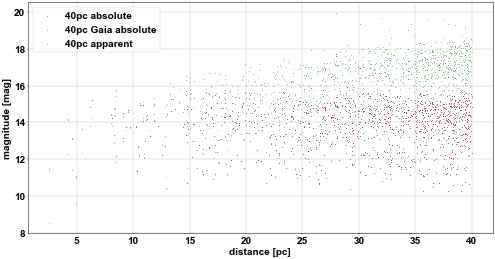

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]

ax[0].scatter(dist_pc_40, absolute_magnitude_40, c='b', label="40pc absolute", s=0.5)
ax[0].scatter(dist_pc_40g, absolute_magnitude_40g, c='r', label="40pc Gaia absolute", s=0.5)
ax[0].scatter(dist_pc_40g, apparent_magnitude_40g, c='g', label="40pc apparent", s=0.5)
ax[0].set_xlabel('distance [pc]')
ax[0].set_ylabel('magnitude [mag]')
ax[0].legend()
ax[0].grid()
fig.set_dpi(30)
plt.show()

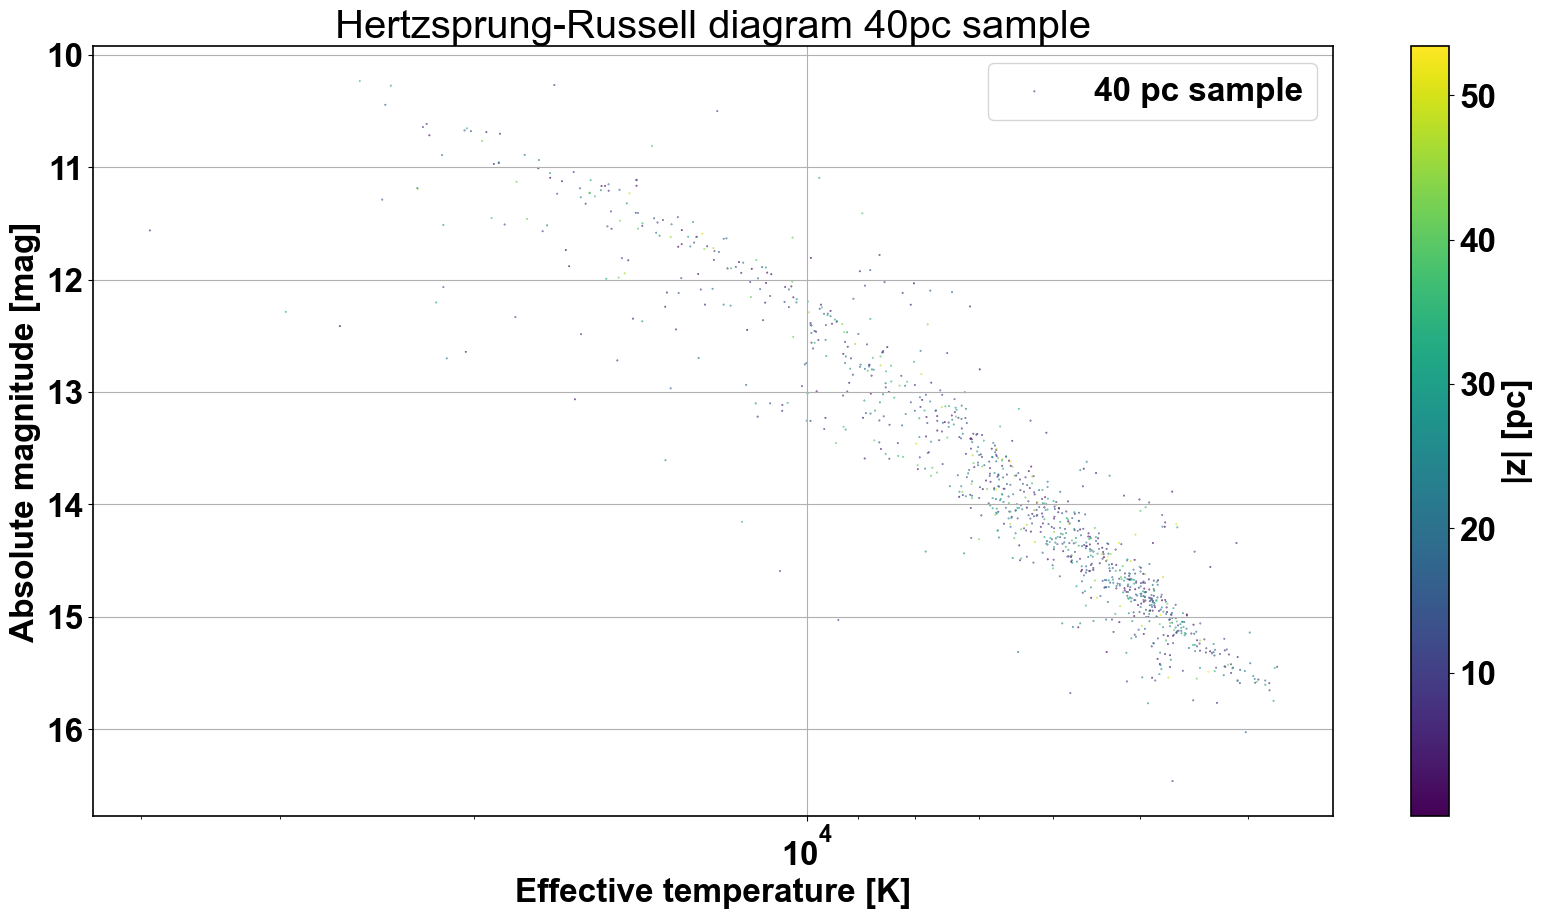

In [30]:
fig, ax = plt.subplots(1, 1, figsize=(20, 10))
ax = [ax]

scatter = ax[0].scatter(teff_40, absolute_magnitude_40, c=np.abs(z_pc_40), marker='.', s=0.5, label='40 pc sample', cmap='viridis')
ax[0].grid()
ax[0].legend(loc='upper right')

ax[0].set_xlabel('Effective temperature [K]')
ax[0].set_ylabel('Absolute magnitude [mag]')
ax[0].set_title('Hertzsprung-Russell diagram 40pc sample')
ax[0].invert_yaxis()
ax[0].invert_xaxis()
ax[0].set_xscale('log')
colorbar = fig.colorbar(scatter, ax=ax, label='|z| [pc]')
plt.show()